# Merging , Joining & Concatenating : 



In [2]:
import pandas as pd
import numpy as np

In [3]:
courses = pd.read_csv(r'C:\Users\ANUBHAV\Data_Analytics\Python\Pandas\Datasets\datasets-session-20\courses.csv')
students = pd.read_csv(r'C:\Users\ANUBHAV\Data_Analytics\Python\Pandas\Datasets\datasets-session-20\students.csv')
nov = pd.read_csv(r'C:\Users\ANUBHAV\Data_Analytics\Python\Pandas\Datasets\datasets-session-20\reg-month1.csv')
dec = pd.read_csv(r'C:\Users\ANUBHAV\Data_Analytics\Python\Pandas\Datasets\datasets-session-20\reg-month2.csv')

matches = pd.read_csv(r'C:\Users\ANUBHAV\Data_Analytics\Python\Pandas\Datasets\datasets-session-20\matches.csv')
delivery = pd.read_csv(r'C:\Users\ANUBHAV\Data_Analytics\Python\Pandas\Datasets\datasets-session-20\deliveries.csv')

In [4]:
courses
students
nov.shape
dec.shape

(28, 2)

## pd.concat  /  df.concat /  ignore_index/  multiindex -> fetch using iloc /  concat dataframes horizontally :


In [5]:
## :: pd.concat : 

## multiple alag-alag dataframes ko vertically stack/merge krta hai. 
pd.concat([nov,dec]).shape

(53, 2)

In [6]:
## ::  ignore index  :

## isse default index aa jayegi serieal wise :
regs = pd.concat([nov,dec], ignore_index = True)
regs.shape


(53, 2)

In [7]:
# :: Multi-index DataFrame :

## aisa dataFrame jisme ak se jyada dataframe exist krte hai.
multi = pd.concat([nov,dec],keys = ['Nov' , 'Dec'])
multi

student_id  course_id
Nov 0           23          1
    1           15          5
    2           18          6
    3           23          4
    4           16          9
    5           18          1
    6            1          1
    7            7          8
    8           22          3
    9           15          1
    10          19          4
    11           1          6
    12           7         10
    13          11          7
    14          13          3
    15          24          4
    16          21          1
    17          16          5
    18          23          3
    19          17          7
    20          23          6
    21          25          1
    22          19          2
    23          25         10
    24           3          3
Dec 0            3          5
    1           16          7
    2           12         10
    3           12          1
    4           14          9
    5            7          7
    6            7          2
    7           16          3
    8           17         10
    9           11          8
    10          14          6
    11          12          5
    12          12          7
    13          18          8
    14           1         10
    15           1          9
    16           2          5
    17           7          6
    18          22          5
    19          22          6
    20          23          9
    21          23          5
    22          14          4
    23          14          1
    24          11         10
    25          42          9
    26          50          8
    27          38          1

In [8]:
multi.loc['Nov']   #--> only nov index wala data

multi.loc['Dec']   #--> only Dec index wala data


,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9
5,7,7
6,7,2
7,16,3
8,17,10
9,11,8


In [9]:
multi.loc[('Nov' , 0)]  # --> Nov dataframe ka 0th index

multi.loc[('Dec' , 0)] # --> Dec dataframe ka 0th index

student_id    3
course_id     5
Name: (Dec, 0), dtype: int64

In [10]:
# :: concat dataframes horizontally : 

## horizontally jod deta hai data ko.

pd.concat([nov,dec] , axis = 1)

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


## Merge : 

### inner join :

In [11]:
## dono dataframe mai se common/ similar dataset ko return krta hai. 

In [12]:
students.merge(regs , how = 'inner' , on = 'student_id')


,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


### left join  :

In [13]:
courses.merge(regs , how = 'left' , on = 'course_id')

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


### right join : 

In [14]:
temp_df = pd.DataFrame({
    'student_id' : [26,27,28],
    'name' : ['Nitish' , 'Ankit' , 'Rahul'],
    'Partner' : [28,26,17]
})

students = pd.concat([students , temp_df],ignore_index = True)

In [15]:
students.tail()

,student_id,name,partner,Partner
23,24,Radhika Suri,17.0,NaN
24,25,Shashank D’Alia,2.0,NaN
25,26,Nitish,NaN,28.0
26,27,Ankit,NaN,26.0
27,28,Rahul,NaN,17.0


In [16]:
students.merge(regs , how = 'right' , on = 'student_id')

,student_id,name,partner,Partner,course_id
0,23,Chhavi Lachman,18.0,NaN,1
1,15,Preet Sha,16.0,NaN,5
2,18,Fardeen Mahabir,13.0,NaN,6
3,23,Chhavi Lachman,18.0,NaN,4
4,16,Elias Dodiya,25.0,NaN,9
5,18,Fardeen Mahabir,13.0,NaN,1
6,1,Kailash Harjo,23.0,NaN,1
7,7,Tarun Thaker,9.0,NaN,8
8,22,Yash Sethi,21.0,NaN,3
9,15,Preet Sha,16.0,NaN,1


### outer join :

In [17]:
students.merge(regs , how = 'outer' , on = 'student_id').tail(10)


,student_id,name,partner,Partner,course_id
53,23,Chhavi Lachman,18.0,NaN,5.0
54,24,Radhika Suri,17.0,NaN,4.0
55,25,Shashank D’Alia,2.0,NaN,1.0
56,25,Shashank D’Alia,2.0,NaN,10.0
57,26,Nitish,NaN,28.0,NaN
58,27,Ankit,NaN,26.0,NaN
59,28,Rahul,NaN,17.0,NaN
60,38,NaN,NaN,NaN,1.0
61,42,NaN,NaN,NaN,9.0
62,50,NaN,NaN,NaN,8.0


### self join : 

In [63]:
## it is a varient of inner join where the second table is the copy of first table.

In [65]:
students.merge(students , how='inner' , left_on = 'partner' , right_on='student_id')[ ['name_x', 'name_y'] ]


,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


## Related Questionos : 

### 1. find total revenue generated : 






In [24]:
total_revenue = regs.merge(courses , how = 'inner' , on = 'course_id')['price'].sum()

print(total_revenue)

154247


### 2. find month by month revenue : 

In [34]:
temp_df = pd.concat([nov, dec],keys = ['Nov' , 'Dec']).reset_index()
temp_df.merge(courses, on='course_id').groupby('level_0')['price'].sum()

level_0
Dec    65072
Nov    89175
Name: price, dtype: int64

### 3. Print the registration table: 
#### [cols : name -> courses -> prices]

In [39]:
regs.merge(students, on='student_id').merge(courses , on = 'course_id')[ ['name' , 'course_name' , 'price'] ]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


### 4. Plot the bar chart for revenue per course : 


<Axes: xlabel='course_name'>

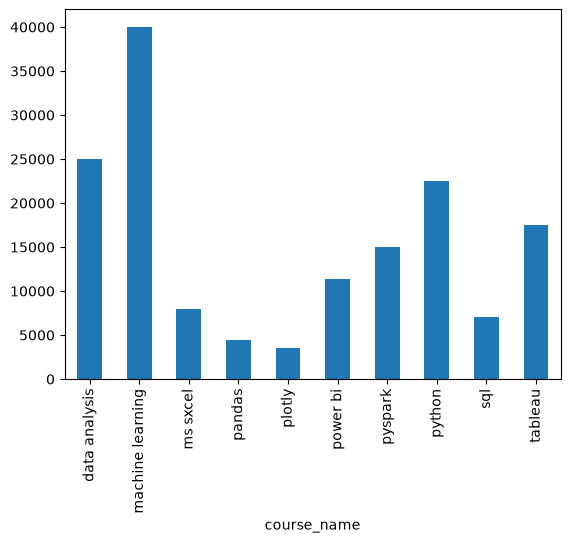

In [45]:
regs.merge(courses , on='course_id').groupby('course_name')['price'].sum().plot(kind='bar')

### 5. Find students who enrolled in both the months :

In [49]:
common_student_id = np.intersect1d(nov['student_id'] , dec['student_id'])
common_student_id

array([ 1,  3,  7, 11, 16, 17, 18, 22, 23])

In [52]:
students[students['student_id'].isin(common_student_id)]

,student_id,name,partner,Partner
0,1,Kailash Harjo,23.0,NaN
2,3,Parveen Bhalla,3.0,NaN
6,7,Tarun Thaker,9.0,NaN
10,11,David Mukhopadhyay,20.0,NaN
15,16,Elias Dodiya,25.0,NaN
16,17,Yasmin Palan,7.0,NaN
17,18,Fardeen Mahabir,13.0,NaN
21,22,Yash Sethi,21.0,NaN
22,23,Chhavi Lachman,18.0,NaN


### 6. find course that got no enrollment : 

In [60]:
course_id_list = np.setdiff1d(courses['course_id'] , regs['course_id'])
courses[courses['course_id'].isin(course_id_list)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


### 7. find students who did not enroll into any courses :


In [62]:
student_id_list = np.setdiff1d(students['student_id'] , regs['student_id'])
students[students['student_id'].isin(student_id_list)]




,student_id,name,partner,Partner
3,4,Marlo Dugal,14.0,NaN
4,5,Kusum Bahri,6.0,NaN
5,6,Lakshmi Contractor,10.0,NaN
7,8,Radheshyam Dey,5.0,NaN
8,9,Nitika Chatterjee,4.0,NaN
9,10,Aayushman Sant,8.0,NaN
19,20,Hanuman Hegde,11.0,NaN
25,26,Nitish,NaN,28.0
26,27,Ankit,NaN,26.0
27,28,Rahul,NaN,17.0


### 8. Print student name -> partner name for all enrolled students :

In [66]:
students.merge(students , how='inner' , left_on = 'partner' , right_on='student_id')[ ['name_x', 'name_y'] ]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


### 9. find the top 3 students who did most number of enrollments : 

In [78]:
regs.merge(students , on = 'student_id').groupby(['student_id' , 'name'])['name'].count().sort_values(ascending=False).head(3)





student_id  name            
23          Chhavi Lachman      6
7           Tarun Thaker        5
14          Pranab Natarajan    4
Name: name, dtype: int64

### 10. find top 3 students who spent most amounts of money on courses : 


In [83]:
regs.merge(students , on = 'student_id').merge(courses,  on='course_id').groupby(['student_id' , 'name'])['price'].sum().sort_values(ascending=False).head(3)


student_id  name            
23          Chhavi Lachman      22594
14          Pranab Natarajan    15096
19          Qabeel Raman        13498
Name: price, dtype: int64

## Alternative syntax for merge : 

In [84]:
pd.merge(students , regs, how='inner',on='student_id')



,student_id,name,partner,Partner,course_id
0,1,Kailash Harjo,23.0,NaN,1
1,1,Kailash Harjo,23.0,NaN,6
2,1,Kailash Harjo,23.0,NaN,10
3,1,Kailash Harjo,23.0,NaN,9
4,2,Esha Butala,1.0,NaN,5
5,3,Parveen Bhalla,3.0,NaN,3
6,3,Parveen Bhalla,3.0,NaN,5
7,7,Tarun Thaker,9.0,NaN,8
8,7,Tarun Thaker,9.0,NaN,10
9,7,Tarun Thaker,9.0,NaN,7


## IPL problems : 


### 1. find top 3 stadiums with highest sixes/match ratio :

In [85]:
matches

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


In [86]:
delivery



,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150455,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
150456,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,0,0,0,CJ Jordan,run out,NV Ojha
150457,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,B Kumar,0,...,0,1,0,0,0,1,1,NaN,NaN,NaN
150458,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,B Kumar,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN


In [88]:
temp_df = delivery.merge(matches , left_on = 'match_id' , right_on = 'id')
temp_df

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150455,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,B Kumar,0,...,normal,0,Sunrisers Hyderabad,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford,NaN
150456,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,B Kumar,0,...,normal,0,Sunrisers Hyderabad,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford,NaN
150457,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,B Kumar,0,...,normal,0,Sunrisers Hyderabad,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford,NaN
150458,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,B Kumar,0,...,normal,0,Sunrisers Hyderabad,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford,NaN


In [92]:
six_df = temp_df[temp_df['batsman_runs'] == 6]

In [95]:
## stadium -> sixes:

num_sixes = six_df.groupby('venue')['venue'].count()
num_sixes


venue
Barabati Stadium                                         68
Brabourne Stadium                                       114
Buffalo Park                                             27
De Beers Diamond Oval                                    34
Dr DY Patil Sports Academy                              173
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium     129
Dubai International Cricket Stadium                      58
Eden Gardens                                            594
Feroz Shah Kotla                                        636
Green Park                                               36
Himachal Pradesh Cricket Association Stadium            108
Holkar Cricket Stadium                                   88
JSCA International Stadium Complex                       76
Kingsmead                                               130
M Chinnaswamy Stadium                                   873
MA Chidambaram Stadium, Chepauk                         507
Maharashtra Cricket Association St

In [97]:
num_matches = matches['venue'].value_counts()
num_matches

venue
M Chinnaswamy Stadium                                   66
Eden Gardens                                            61
Feroz Shah Kotla                                        60
Wankhede Stadium                                        57
Rajiv Gandhi International Stadium, Uppal               49
MA Chidambaram Stadium, Chepauk                         48
Punjab Cricket Association Stadium, Mohali              35
Sawai Mansingh Stadium                                  33
Dr DY Patil Sports Academy                              17
Subrata Roy Sahara Stadium                              17
Maharashtra Cricket Association Stadium                 15
Kingsmead                                               15
SuperSport Park                                         12
Sardar Patel Stadium, Motera                            12
Punjab Cricket Association IS Bindra Stadium, Mohali    11
Brabourne Stadium                                       11
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadiu

In [99]:
## result :

result = (num_sixes/num_matches).sort_values(ascending=False).head(3)
result 


venue
Holkar Cricket Stadium     17.600000
M Chinnaswamy Stadium      13.227273
Sharjah Cricket Stadium    12.666667
dtype: float64

### 2. Find orange cap holder of all the seasons : 

In [102]:
temp_df = delivery.merge(matches , left_on = 'match_id' , right_on = 'id')
temp_df

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150455,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,B Kumar,0,...,normal,0,Sunrisers Hyderabad,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford,NaN
150456,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,B Kumar,0,...,normal,0,Sunrisers Hyderabad,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford,NaN
150457,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,B Kumar,0,...,normal,0,Sunrisers Hyderabad,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford,NaN
150458,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,B Kumar,0,...,normal,0,Sunrisers Hyderabad,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford,NaN


In [109]:
temp_df.groupby(['season' , 'batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs' , ascending=False).drop_duplicates(subset=['season'], keep='first').sort_values('season')






,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641
